In [47]:
import numpy as np
import os
import json
import matplotlib.pyplot as plt

In [28]:
# Specify the directory where the JSON files are stored
directory = './'

# List all JSON files in the directory
json_files = [f for f in os.listdir(directory) if f.endswith('.json')]

print(json_files)

['logs_20250112_151319.json']


In [29]:
filename = json_files[0]
# Load the JSON file
with open(filename, 'r') as file:
    data = json.load(file)

# Print the loaded data
print(data)

{'control_effort': [0.11072418127473052, 0.07177897215774244, 0.08550566596663335, 0.08061068676129739, 0.08175309137732989, 0.08024502544242398, 0.07959713662536085, 0.07843978993720796, 0.07755661095704469, 0.07643121460725211, 0.07551723570475265, 0.07452606038935694, 0.07356187246309502, 0.07245665686187175, 0.07140232581719048, 0.07046228188849026, 0.06948241429015609, 0.06838630746266199, 0.06746385917370042, 0.06648052855721565, 0.06538874514423848, 0.06433661773904206, 0.06327141360384798, 0.06221186068118109, 0.06128191143042909, 0.06017603600131559, 0.05926414976717121, 0.058153527283990446, 0.057114455909324804, 0.05618101858304386, 0.055080439605338115, 0.05417025216870307, 0.05306287224078758, 0.05215641658738142, 0.05117908023417718, 0.0502275626666213, 0.04913761359056221, 0.04822738920627823, 0.04712407176712333, 0.04609012872422276, 0.045032159935492325, 0.04411291831091367, 0.04314483614776053, 0.0421946352780621, 0.04110917458428535, 0.0402017488753155, 0.03910215033

In [30]:
print(data.keys())

dict_keys(['control_effort', 'computation_time', 'norm_inputs', 'endpoint_tracking_error', 'drone_position'])


In [55]:
print(np.array(data['control_effort']).shape)
print(np.array(data['computation_time']).shape)
print(np.array(data['norm_inputs']).shape)
print(np.array(data['endpoint_tracking_error']).shape)
print(np.array(data['drone_position']).shape)

(1371,)
(1371,)
(1371, 3)
(5,)
(1371, 3)


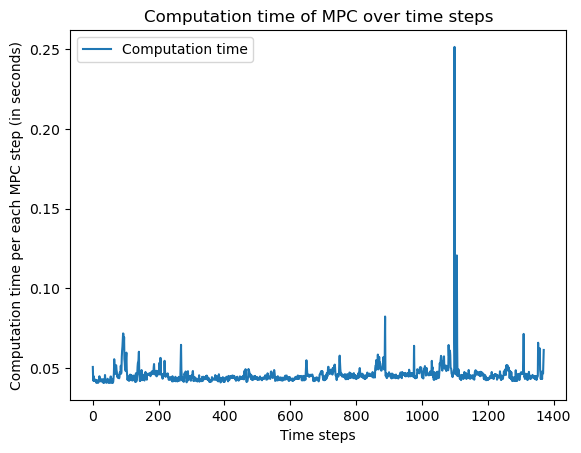

In [54]:
def plot_computation_time(data):
# Create the plot
    plt.plot(data, label='Computation time')

    # Add labels and title
    plt.xlabel('Time steps')
    plt.ylabel('Computation time per each MPC step (in seconds)')
    plt.title('Computation time of MPC over time steps')

    # Add a legend
    plt.legend()

    # Show the plot
    plt.show()

comp_time = data['computation_time']
plot_computation_time(comp_time)

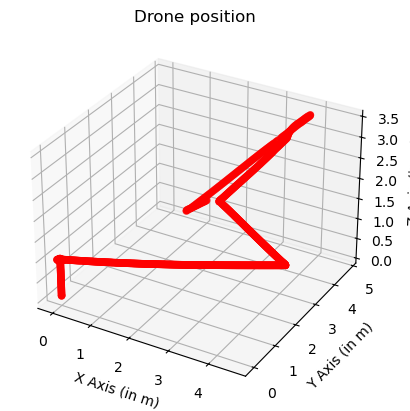

In [59]:
def plot_3d_pos(x,y,z):
    # Create a figure
    fig = plt.figure()

    # Add a 3D subplot
    ax = fig.add_subplot(111, projection='3d')

    # Scatter plot
    ax.scatter(x,y,z, c='r', marker='o')

    # Add labels
    ax.set_xlabel('X Axis (in m)')
    ax.set_ylabel('Y Axis (in m)')
    ax.set_zlabel('Z Axis (in m)')
    ax.set_title('Drone position')

    # Show the plot
    plt.show()

x,y,z = np.array(data['drone_position'])[:, 0],np.array(data['drone_position'])[:, 1],np.array(data['drone_position'])[:, 2]
plot_3d_pos(x,y,z)

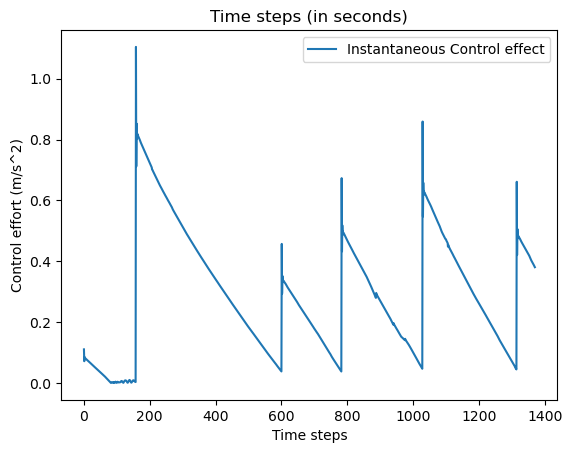

In [64]:
def plot_control_effort(data):
# Create the plot
    plt.plot(data, label='Instantaneous Control effect')

    # Add labels and title
    plt.xlabel('Time steps')
    plt.ylabel('Control effort (m/s^2)')
    plt.title('Time steps (in seconds)')

    # Add a legend
    plt.legend()

    # Show the plot
    plt.show()

contr_eff = data['control_effort']
plot_control_effort(contr_eff)

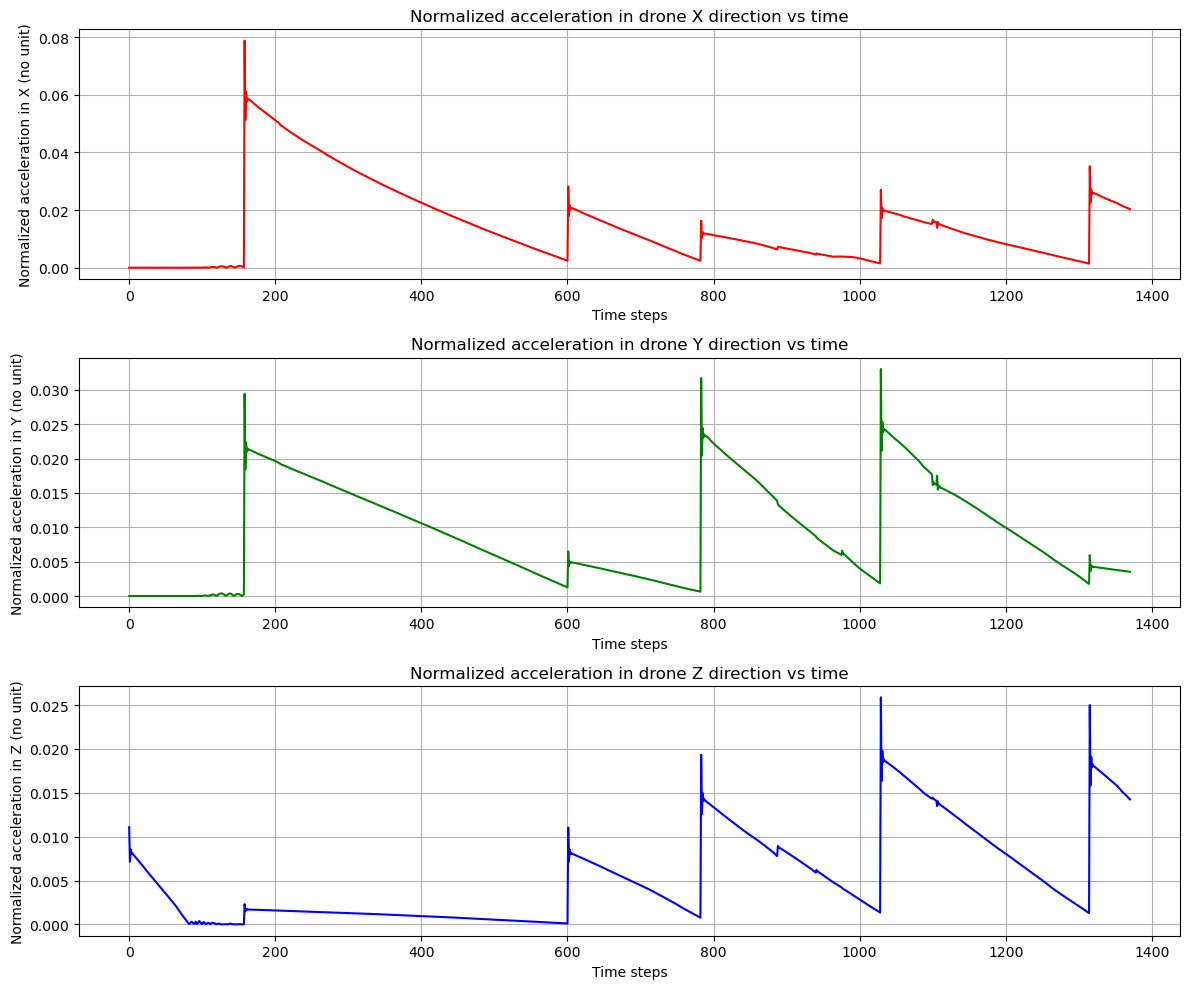

In [81]:
def plot_norm_inputs(x,y,z):
    # Create a figure
    plt.figure(figsize=(12, 10))


    plt.subplot(3, 1, 1)  
    plt.plot(x, color='r')
    plt.title('Normalized acceleration in drone X direction vs time')
    plt.xlabel('Time steps')
    plt.ylabel('Normalized acceleration in X (no unit)')
    plt.grid(True)


    plt.subplot(3, 1, 2)
    plt.plot(y, color='g')
    plt.title('Normalized acceleration in drone Y direction vs time')
    plt.xlabel('Time steps')
    plt.ylabel('Normalized acceleration in Y (no unit)')
    plt.grid(True)


    plt.subplot(3, 1, 3) 
    plt.plot(z, color='b')
    plt.title('Normalized acceleration in drone Z direction vs time')
    plt.xlabel('Time steps')
    plt.ylabel('Normalized acceleration in Z (no unit)')
    plt.grid(True)

    # Adjust layout for better spacing
    plt.tight_layout()

    # Show the plot
    plt.show()

x_norm, y_norm, z_norm = np.array(data['norm_inputs'])[:, 0],np.array(data['norm_inputs'])[:, 1],np.array(data['norm_inputs'])[:, 2]
plot_norm_inputs(x_norm, y_norm, z_norm)

/tmp/ipykernel_885345/762725641.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


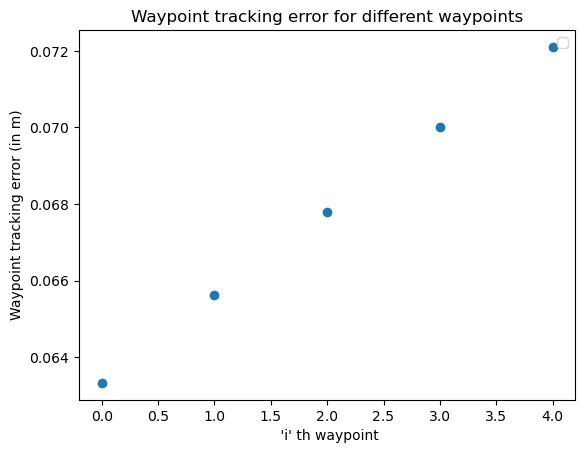

In [89]:
def plot_waypoint_tracking_error(data):
# Create the plot
    plt.scatter(np.arange(len(data)),data)

    # Add labels and title
    plt.xlabel(""" 'i' th waypoint""")
    plt.ylabel('Waypoint tracking error (in m)')
    plt.title('Waypoint tracking error for different waypoints')

    # Add a legend
    plt.legend()

    # Show the plot
    plt.show()

waypoints_trac_error = data['endpoint_tracking_error']
plot_waypoint_tracking_error(waypoints_trac_error)